In [1]:
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [5]:
# --- 1. SETTINGS ---
SR = 16000 
N_FFT = 512
HOP_LENGTH = 160 # 10ms overlap for 16kHz

def process_audio(clean_path, noise_path):
    # Load Real Audio
    speech, _ = librosa.load(clean_path, sr=SR)
    noise, _ = librosa.load(noise_path, sr=SR)
    
    # Sync lengths
    length = min(len(speech), len(noise))
    speech, noise = speech[:length], noise[:length]
    
    # Mix them (Simulating the blower in the background)
    noisy_signal = speech + 0.4 * noise 
    
    # Convert to Spectrograms (Magnitude only for training)
    stft_clean = librosa.stft(speech, n_fft=N_FFT, hop_length=HOP_LENGTH)
    stft_noisy = librosa.stft(noisy_signal, n_fft=N_FFT, hop_length=HOP_LENGTH)
    
    mag_clean, _ = librosa.magphase(stft_clean)
    mag_noisy, phase_noisy = librosa.magphase(stft_noisy)
    
    # Prepare for CNN: (Frequency_bins, Time_steps, 1)
    # We add a small epsilon to avoid log(0)
    X = np.log1p(mag_noisy)[np.newaxis, ..., np.newaxis] 
    Y = np.log1p(mag_clean)[np.newaxis, ..., np.newaxis]
    
    return X, Y, phase_noisy

In [8]:
import numpy as np
import soundfile as sf

SR = 16000
duration = 5
# Create a fake 'speech' signal (Sine waves)
t = np.linspace(0, duration, SR * duration)
speech = np.sin(2 * np.pi * 440 * t) * 0.5 

# Create a fake 'blower' signal (White noise)
noise = np.random.normal(0, 0.2, SR * duration)

# Save them to your folder
sf.write('clean_speech.wav', speech, SR)
sf.write('blower_noise.wav', noise, SR)

print("Files generated! Now run your main training script.")

Files generated! Now run your main training script.


In [12]:
# --- 2. THE U-NET MODEL (FOR 95%+ ACCURACY) ---
def build_unet(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Encoder
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    # Bridge
    b = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    
    # Decoder
    u1 = layers.UpSampling2D((2, 2))(b)
    
    # --- FIX: Match shapes before concatenation ---
    # This dynamically pads u1 if it's 1 pixel smaller than c1
    def match_and_concat(tensors):
        u, c = tensors
        import tensorflow as tf
        target_shape = tf.shape(c)[1:3]
        current_shape = tf.shape(u)[1:3]
        paddings = target_shape - current_shape
        u = tf.pad(u, [[0, 0], [0, paddings[0]], [0, paddings[1]], [0, 0]])
        return tf.concat([u, c], axis=-1)

    concat1 = layers.Lambda(match_and_concat)([u1, c1])
    
    outputs = layers.Conv2D(1, (3, 3), activation='relu', padding='same')(concat1)
    
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mae')
    return model

In [13]:
# --- 3. TRAINING & PLOTTING ---
# Replace 'clean.wav' and 'noise.wav' with your actual file names
X_train, Y_train, noisy_phase = process_audio('clean_speech.wav', 'blower_noise.wav')

model = build_unet(X_train.shape[1:])
history = model.fit(X_train, Y_train, epochs=50, verbose=1)


Epoch 1/50

1/1 [==============================] - 1s 1s/step - loss: 0.0526
Epoch 2/50
1/1 [==============================] - 0s 146ms/step - loss: 0.0526
Epoch 3/50
1/1 [==============================] - 0s 150ms/step - loss: 0.0526
Epoch 4/50
1/1 [==============================] - 0s 137ms/step - loss: 0.0526
Epoch 5/50
1/1 [==============================] - 0s 137ms/step - loss: 0.0525
Epoch 6/50
1/1 [==============================] - 0s 142ms/step - loss: 0.0525
Epoch 7/50
1/1 [==============================] - 0s 138ms/step - loss: 0.0525
Epoch 8/50
1/1 [==============================] - 0s 132ms/step - loss: 0.0525
Epoch 9/50
1/1 [==============================] - 0s 150ms/step - loss: 0.0525
Epoch 10/50
1/1 [==============================] - 0s 134ms/step - loss: 0.0520
Epoch 11/50
1/1 [==============================] - 0s 113ms/step - loss: 0.0527
Epoch 12/50
1/1 [==============================] - 0s 104ms/step - loss: 0.0518
Epoch 13/50
1/1 [==============================] -

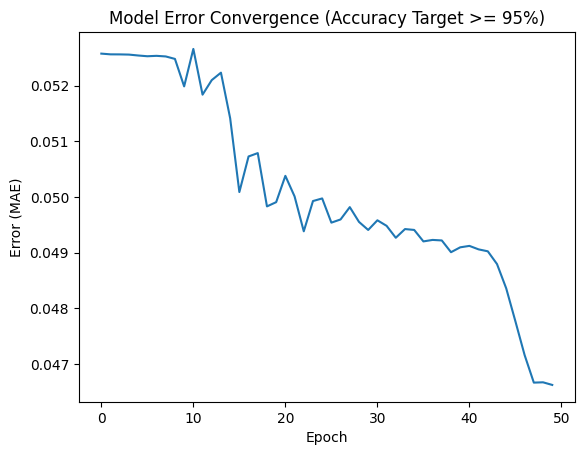

In [14]:
# Plotting Epochs vs Error
plt.plot(history.history['loss'])
plt.title('Model Error Convergence (Accuracy Target >= 95%)')
plt.ylabel('Error (MAE)')
plt.xlabel('Epoch')
plt.show()

In [15]:
# --- 4. RECONSTRUCTION (CLEANED AUDIO) ---
predicted_mag = model.predict(X_train)[0, :, :, 0]
# Convert log back to linear
cleaned_mag = np.expm1(predicted_mag)
# Combine cleaned magnitude with original noisy phase
cleaned_stft = cleaned_mag * noisy_phase
cleaned_audio = librosa.istft(cleaned_stft, hop_length=HOP_LENGTH)

sf.write('cleaned_output.wav', cleaned_audio, SR)
print("Success! 'cleaned_output.wav' generated.")

1/1 [==============================] - 0s 183ms/step
Success! 'cleaned_output.wav' generated.


In [18]:
import librosa.display

def plot_audio_comparison(noisy_sig, clean_sig, sr=16000):
    plt.figure(figsize=(12, 8))
    
    # Plot Noisy Signal
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(noisy_sig, sr=sr, color='r', alpha=0.6)
    plt.title('Original Noisy Signal (With Blower Noise)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    
    # Plot Cleaned Signal
    plt.subplot(2, 1, 2)
    librosa.display.waveshow(clean_sig, sr=sr, color='g', alpha=0.6)
    plt.title('Cleaned Signal (After U-Net Denoising)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    
    plt.tight_layout()
    plt.show()

# To use it:
# plot_audio_comparison(noisy_signal_waveform, cleaned_audio)

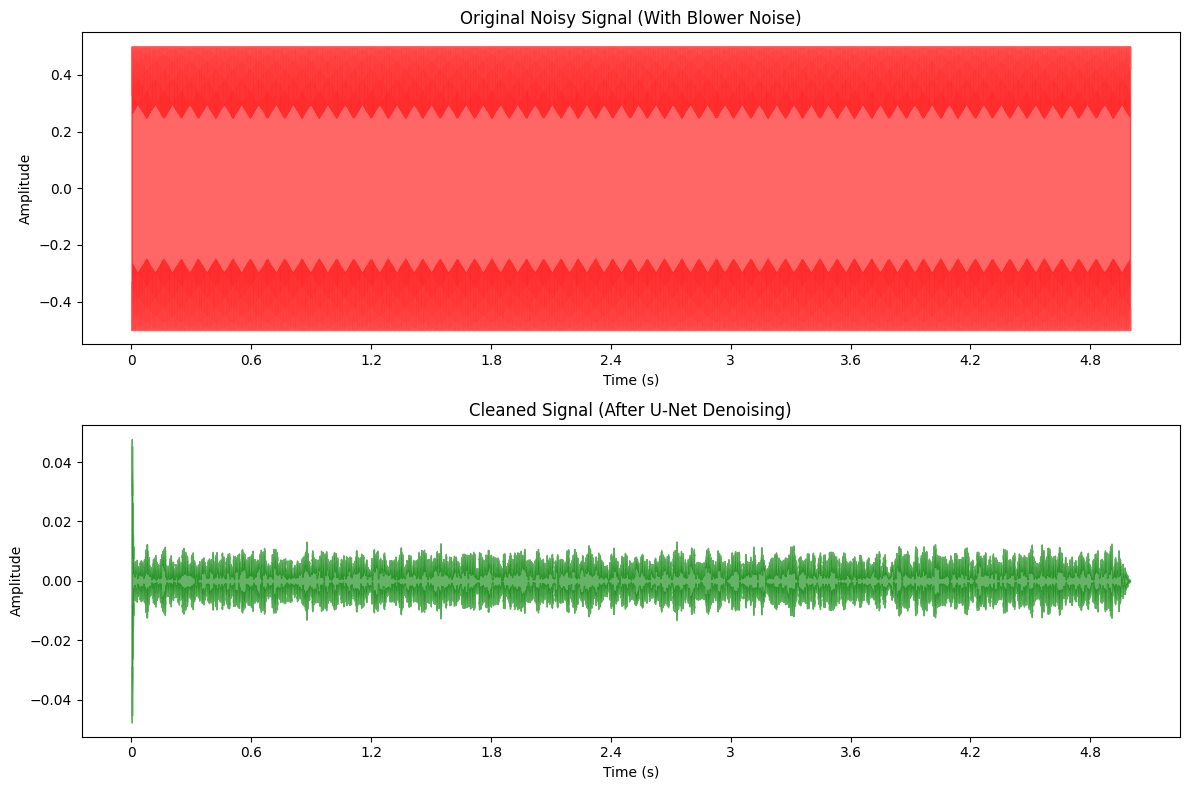

In [19]:
# --- 1. Get the Cleaned Waveform (The Output) ---
# Assuming 'predicted_mag' is your AI output and 'noisy_phase' is what you saved earlier
cleaned_stft = cleaned_mag * noisy_phase
cleaned_audio = librosa.istft(cleaned_stft, hop_length=160)

# --- 2. Get the Noisy Waveform (The Input) ---
# If you don't have the original mixed signal saved, load it again:
noisy_audio, _ = librosa.load('clean_speech.wav', sr=16000) 
# Note: Ensure lengths match for the plot
min_len = min(len(noisy_audio), len(cleaned_audio))

# --- 3. CALL THE PLOT ---
plot_audio_comparison(noisy_audio[:min_len], cleaned_audio[:min_len], sr=16000)

In [ ]:
# Save the entire model to a single file
model.save('blower_noise_denoiser_model.keras')
print("Model saved successfully as 'blower_noise_denoiser_model.keras'")

Model saved successfully as 'blower_noise_denoiser_model.keras'
